# Building Grid

In [1]:


#--LIBRARIES--------

#numerics
import numpy as np
import eelib

#visualization
#import seaborn #statistical data visualization
#import matplotlib
#import matplotlib.pyplot as plt
#from mpl_toolkits import Axes3D #projection
#import plotly.express as px #3D plot



#--CODE--

# set parameters
# note that k, B, and R are percents here, mu is not as its scale is unknown
k = 0.5
R = 0.8
B = 0.5
mu = 1.0e-7

n_k = 10
n_m = 20
n_g = 21

#m_min = 0.5
#m_max = 2
#k_min = 0.5
#k_max = 0.7
a_min = 0.5
a_max = 3.0
mu_min = -8 #1.0e-8
mu_max = -5 #1.0e-5

pr = 200
n = 20


#make loop, grid, or system
#loopl = eelib.loop(R, B, k, mu)#, grid_size=n_g)
#loopl = eelib.deriv_grid(R, B, k, mu, grid_size=n_g)
#gridl = parameterGrid(n_R, n_B, n_k, n_m, mu_min=mmin, mu_max=mmax, dk_max=kmax, dk_min=kmin)
gridl = eelib.grid_fast_osc(R, B, k, mu, grid_size = n_g)


# solve the ivp or bvp
#loopl.solve_ivp()
#loopl.setDeriv(-7003921000.852429+12357828925.240108j)

#maxX = n*loopl.T0
#per_range = maxX / loopl.lngt

#rtol = 2.0e-6
#atol = 1.0e-10

#sol1 = loopl.call_ivp_solver(0.0, loopl.lngt *per_range, loopl.amp, loopl.psi0_deriv_0, ee_int = True, rtol=rtol, atol=atol) # find the first n cycles
#sol2 = loopl.call_ivp_solver(0.0, loopl.lngt *per_range, loopl.amp, loopl.psi0_deriv_0, ee_int = False,rtol=rtol,atol=atol) # find the first n cycles

#loopl.solve_ivp(n = n, percent_range = pr, solve=0)
#loopl.findDeriv()
#loopl.derivGrid()
    
#loopl.saveDerivGrid()
#gridl.save_data()
#n = 2

gridl.makeGridPoints(a_min, a_max, mu_min, mu_max, num = n_k, num_m=n_m)
gridl.gridFastOsc()

# --- PLOTTING FOR GRIDS ---
#for i in range(n_g):
#    for j in range(n_g):
#        loopl.plot_abs(i,j,k,R,B,mu,n)
#        loopl.plot_real(i,j,k,R,B,mu,n)
#        plot_img(loopl,i,j,k,R,B,mu)




Begin grid build:  0.0
0 0 1.022995948791504
0 1 190.86469101905823
0 2 354.58139395713806
0 3 509.2299470901489
0 4 669.9776086807251
0 5 835.1611037254333
0 6 1004.2428812980652
0 7 1162.8362460136414
0 8 1321.4860255718231
0 9 1516.9183597564697
1 0 1698.498385667801
1 1 1880.0118782520294
1 2 2045.053246974945
1 3 2211.6025018692017
1 4 2370.974135875702
1 5 2531.1616566181183
1 6 2693.629223585129
1 7 2855.9666550159454
1 8 3018.2526338100433
1 9 3182.020670413971
2 0 3348.2567336559296
2 1 3516.284865617752
2 2 3679.3901896476746
2 3 3840.856772661209
2 4 4012.131455898285
2 5 4174.641508340836
2 6 4332.031126737595
2 7 4538.30553650856
2 8 4723.209323644638
2 9 4893.553370475769
3 0 5055.074929475784
3 1 5217.51099562645
3 2 5374.74523639679
3 3 5530.321861982346
3 4 5678.209782361984
3 5 5842.762897729874
3 6 6019.315665960312
3 7 6178.10205745697
3 8 6336.612097263336
3 9 6496.716349601746
4 0 6656.74219250679
4 1 6819.642175197601
4 2 6978.201979398727
4 3 7131.488821983337
4

# Defining variables for analysis

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy

In [2]:
# independent variables
#mfp = gridl.mfp
#ew = gridl.ew
nls = gridl.nls
amp = gridl.amp
dgrid = gridl.d0_grid

# dependent variables
foa = gridl.fast_osc_a
fot = gridl.fast_osc_t

In [3]:
t_1 = eelib.pi/(eelib.kFAu)

In [4]:
t_new  = eelib.pi/(gridl.l_calc.k)
#=eelib.pi/(eelib.kFAu+gridl.l_calc.M/4)

In [8]:
size = np.shape(foa.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

print(size == n_k* n_m * n_g**2)

sz = [n_k * n_g **2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ia in range(n_k):
        for idr in range(n_g):
            for idi in range(n_g):
                ind = imu*sz[0]+ia*sz[1]+idr*sz[2]+idi
                #npaf[ind, 0] = mfp[im]
                #npaf[ind, 1] = ew[ik]
                npaf[ind, 0] = nls[imu]
                npaf[ind, 1] = amp[ia]
                npaf[ind, 2] = np.real(dgrid[idr, idi])
                npaf[ind, 3] = np.imag(dgrid[idr, idi])
                npaf[ind, 4] = foa[imu, ia, idr, idi]
                npaf[ind, 5] = fot[imu, ia, idr, idi]

88200
True


In [9]:
dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "T fast"])

In [10]:
dfa

,mu,A0,D re,D im,A max,T fast
0,1.000000e-08,0.5,-1.480043e+10,-1.480043e+10,1.781224,2.617933e-10
1,1.000000e-08,0.5,-1.442301e+10,-1.480043e+10,1.758715,2.617932e-10
2,1.000000e-08,0.5,-1.373414e+10,-1.480043e+10,1.718294,2.617932e-10
3,1.000000e-08,0.5,-1.274871e+10,-1.480043e+10,1.662062,2.617931e-10
4,1.000000e-08,0.5,-1.148799e+10,-1.480043e+10,1.593140,2.617930e-10
...,...,...,...,...,...,...
88195,1.000000e-05,3.0,1.148799e+10,1.480043e+10,3.182065,2.661287e-10
88196,1.000000e-05,3.0,1.274871e+10,1.480043e+10,3.221907,2.662146e-10
88197,1.000000e-05,3.0,1.373414e+10,1.480043e+10,3.255353,2.662881e-10
88198,1.000000e-05,3.0,1.442301e+10,1.480043e+10,3.279885,2.663429e-10


# $\mu$ linear regression fitting

This is a straight line, find the intercept for various variants. 

Find all slopes and intercepts, then determine if it matches the expected results. ...

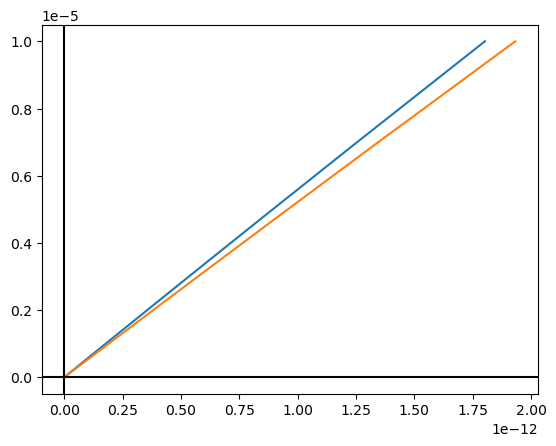

In [ ]:
k1 = 3
k2 = 4
d1 = 0
d2 = 0
d3 = 1
d4 = 3

fig, ax = plt.subplots()
ax.plot(fot[:, k1,d1,d2]-t_new,nls)
ax.plot(fot[:, k2,d3,d4]-t_new,nls)
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

y = a x + b
y1 - y2 = a (x1 - x2)
b = y - a x

In [ ]:
slope = np.zeros((n_k,n_g,n_g))
intercept = np.zeros((n_k,n_g,n_g))
r = 1    # for finding the minimum r value

for i in range(n_k):
    for j in range(n_g):
        for k in range(n_g):
            xx = nls
            yy = fot[:, i, j, k]

            sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

            slope[i,j,k]=sl
            intercept[i,j,k]=interc

            r = min(r, r2)
            #p = max(p, p2)
            #se = max(se, se2)

            print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0 0 0 1.2237545812028646e-07 2.6179139728674757e-10
0 0 1 1.1949857325630035e-07 2.617913985088784e-10
0 0 2 1.1443606114608955e-07 2.61791437085926e-10
0 0 3 1.0764070199446358e-07 2.6179149032773925e-10
0 0 4 9.968049105962005e-08 2.6179158474165946e-10
0 0 5 9.126859731405657e-08 2.6179162871140745e-10
0 0 6 8.311273154558008e-08 2.617916475999171e-10
0 0 7 7.591154926655136e-08 2.6179166464014847e-10
0 0 8 7.028308468582332e-08 2.6179166641706307e-10
0 0 9 6.669791464108725e-08 2.617917095245782e-10
0 0 10 6.54744009988165e-08 2.617916719599642e-10
0 0 11 6.670227879247053e-08 2.6179171344881283e-10
0 0 12 7.028276589454073e-08 2.617916848961212e-10
0 0 13 7.59089593388274e-08 2.61791690184306e-10
0 0 14 8.311069216536128e-08 2.6179165775170395e-10
0 0 15 9.126630718372136e-08 2.617916510372498e-10
0 0 16 9.968578350720656e-08 2.617915504375629e-10
0 0 17 1.0763677605467027e-07 2.617915071821309e-10
0 0 18 1.1443801236583947e-07 2.617914569712354e-10
0 0 19 1.1949721183221498e-07 2

In [26]:
print(t_new-np.average(intercept), t_new-np.min(intercept), t_new-np.max(intercept))
print(1/np.average(intercept)-1/t_new)
#print(1/np.average(intercept)-1/t_1)

2.2150440808093696e-15 7.41961964810364e-15 4.684558562745638e-16
32320.004599571228


In [27]:
print((1/np.average(intercept)-1/t_new)/eelib.pi)

10287.77698554911


In [29]:
print(np.sqrt(gridl.l_calc.M))

1987.4846828301415


In [30]:
np.max(slope), np.min(slope)

(4.559739510059996e-07, 9.192797457893529e-09)

Linear dependence of mu vs t - t_0

Result for intercept, add to k: 111873.9875407219
independent of A_0 and psi'
dependent on mu (I think), but may just be numerical error (can be checked with alternative ranges of mu)
if mu dependence is numerical error, the intercept itself is numerical error, and should be zero
dependence on k, dk, and B unknown
Note that the intercept is t_0 (the period without mu)

The greatest p values are:
R2: 0.9999976281979924 
p: 1.3844923187575803e-22 
se: 3.028692221455953e-10

Previous calculations show that slope is independent of mu while intercept depends on mu. Indicates that there is a mu*f(a_0, psi'_0)+ g(mu, k, B) structure.

Slope dependent on i, j, k, but not on l1, l2. Intercept negative and becomes more negative for larger l1, l2. -10^-15 is smallest, compared to 10^-13 dt or 10^-10 t 

Plot this with respect to mu, psi', psi
.... probably ignore this
grab the slope and average or maximum intercept
.... 


.... put in terms of k^2

In [37]:
np.abs(dgrid[j,k]/gridl.l_calc.k)

1.7442017094256994

# $A_0$ and $\Psi^\prime_0$ Regression

mu*f(a_0, psi'_0)+ g(mu, k, B)

The slope here is approximately constant, while the intercept varies.

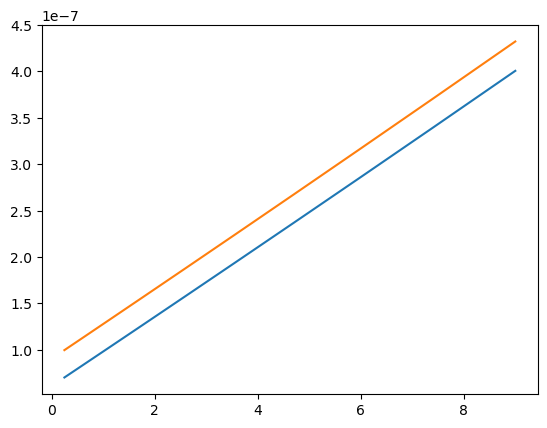

In [40]:
d1 = 0
d2 = 12
d3 = 3
d4 = 2

fig, ax = plt.subplots()
ax.plot(amp**2,slope[:,d1,d2])
ax.plot(amp**2,slope[:,d3,d4])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

#fig, ax = plt.subplots()
#ax.plot(amp**2,slope[:,3,2])
#plt.show()

#fig, ax = plt.subplots()
#ax.plot(fot[:, 4,1,1]-t_new,nls)
#plt.show()

In [41]:
np.shape(slope)

(10, 21, 21)

In [42]:
slope2 = np.zeros((n_g,n_g))
intercept2 = np.zeros((n_g,n_g))
r = 1

for j in range(n_g):
    for k in range(n_g):
        xx = amp**2
        yy = slope[:,j,k]

        sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

        slope2[j,k]=sl
        intercept2[j,k]=interc

        r = min(r, r2)

        print(j, k, slope2[j,k], intercept2[j,k], r2)

print(np.average(slope2), r)

0 0 3.8091966309274166e-08 1.1221127283019272e-07 0.9999887944142256
0 1 3.8070373653053236e-08 1.0933809627517779e-07 0.9999887784027609
0 2 3.803332053858246e-08 1.0428616507310998e-07 0.9999888417157213
0 3 3.798297633778213e-08 9.750046511606798e-08 0.9999888418558087
0 4 3.792398013173892e-08 8.956558606846316e-08 0.9999890024239707
0 5 3.786195681007659e-08 8.116832313693239e-08 0.9999890087115454
0 6 3.780160243043775e-08 7.303056021834967e-08 0.999989092657886
0 7 3.7749075197636646e-08 6.584533909546652e-08 0.9999891787924496
0 8 3.770716846787657e-08 6.023000927681639e-08 0.9999892323329664
0 9 3.7681185262270485e-08 5.665625772005843e-08 0.9999892584288691
0 10 3.7672964355537604e-08 5.543198547199078e-08 0.9999892320797983
0 11 3.768191977070415e-08 5.665713035652863e-08 0.9999892728896138
0 12 3.770780448774802e-08 6.022922199418932e-08 0.9999892455657081
0 13 3.774930458202902e-08 6.584550751705541e-08 0.9999891458193865
0 14 3.780262951192582e-08 7.302976245683949e-08 0.

Slope is almost independent of psi', intercept is not.

Slope: 3.698062210078747e-08 

r: 0.9999992783744597 

p: 1.186383953629946e-24 

se:1.5713552843315777e-11

Source of slope in units???


In [43]:
slope_A = np.average(slope2)
(np.std(slope2))/slope_A

0.0047722971206014195

In [44]:
dlist = np.real(dgrid[1])

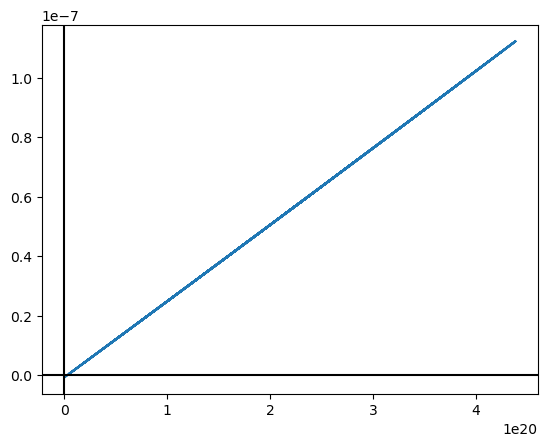

In [48]:
fig, ax = plt.subplots()
ax.plot(np.abs(dgrid.flatten())**2,intercept2.flatten())
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

Already not so clear. Error is visible. Intercept not zero.
The zig-zag and intercept can be due to a splitting of the real and imaginary components of the derivative. Perhaps I should separate them already.

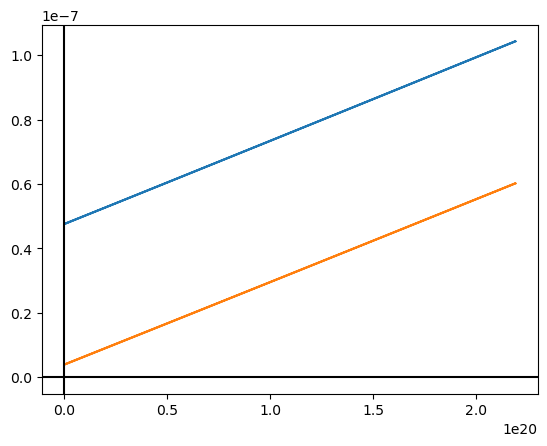

In [54]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.real(dgrid[2])**2,intercept2[d1])
ax.plot(np.real(dgrid[2])**2,intercept2[d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

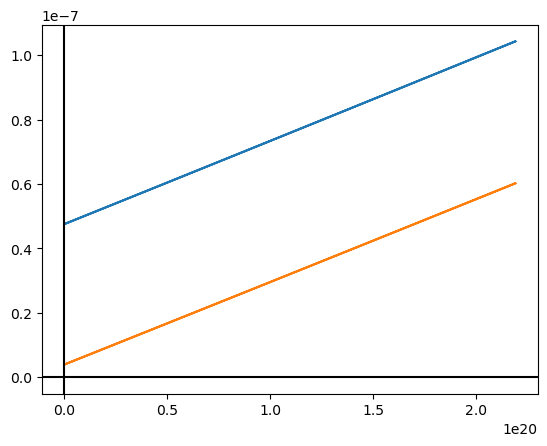

In [53]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.imag(dgrid[:,2])**2,intercept2[:,d1])
ax.plot(np.imag(dgrid[:,2])**2,intercept2[:,d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

The zig-zag has not been removed. I will try to fit these two components, and see what remains. The zig-zag may be an artifact of plotting, despite the fact that I didn't see it before. My assumption is a  $\frac{|psi^\prime|^2}{k}$ term with the same slope as A_0, an additional imag psi ' term, and non-linear mu terms.

And there may be an error due to k here being k_new, not k_0. Perhaps fit with a recurrsive formula; one correction to k should be enough here. I think that there is a term, non-linear in mu, which produces a stronger result.

In [57]:

xx = np.abs(dgrid.flatten())**2
yy = intercept2.flatten()

sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)

print(sl/t_new**2*eelib.pi**2, interc, r2)


3.712978769853231e-08 -9.987401301876449e-10 0.9999953746219353


R values still good. Slope close to A_0 slope, as it should be, but closer if -intercept is added. Assume no intercept and A_0 slope is correct for (psi'_0 / k)^2 I still don't know what the A_0 slope comes from. I need to check my constants. 

In [59]:
slope3 = []
intercept3 = []

for i in range(n_g):
    xx = np.real(dgrid[i])**2
    yy = intercept2[i]

    sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)
    slope3.append(sl)
    intercept3.append(interc)

    print(sl/t_new**2*eelib.pi**2, interc, r2)

3.732643198974281e-08 5.539371172408226e-08 0.999999067138905
3.730623326560941e-08 5.254971716447249e-08 0.9999990427683406
3.7271129460080307e-08 4.755168609763967e-08 0.9999990630442146
3.722316448795392e-08 4.083572574681899e-08 0.9999990587267044
3.7167630772112334e-08 3.298177271829799e-08 0.9999990767351721
3.7110630854684495e-08 2.466871472796679e-08 0.9999990794510734
3.7053874803067386e-08 1.661254798010198e-08 0.9999990970659822
3.7002332516488454e-08 9.501983866907701e-09 0.9999991022380808
3.696479378750576e-08 3.939920723714455e-09 0.9999991089687137
3.6939311702801825e-08 4.0302458624193e-10 0.9999991017932012
3.6930238577824506e-08 -8.119069657972706e-10 0.999999096685122
3.693910407722859e-08 3.968203502839496e-10 0.999999102284271
3.6964929045018684e-08 3.927038332662623e-09 0.9999991070347272
3.700247505247405e-08 9.483321544706612e-09 0.9999990943753956
3.705358336878587e-08 1.6588500597680685e-08 0.9999991057371032
3.711061545221384e-08 2.463949613053577e-08 0.9999

Visible imag(psi') dependence on slope at around the % level.

In [60]:
slope4 = []
intercept4 = []

for i in range(n_g):
    xx = np.imag(dgrid[:,i])**2
    yy = intercept2[:,i]

    sl, interc, r2, p2, se2  = scipy.stats.linregress(xx, yy)
    slope4.append(sl)
    intercept4.append(interc)

    print(sl/t_new**2*eelib.pi**2, interc, r2)

3.733337284365883e-08 5.536180326986586e-08 0.9999987603730586
3.731297913367989e-08 5.251966946324101e-08 0.9999987584310768
3.727722369796132e-08 4.752411017094329e-08 0.9999987925360999
3.722953871374849e-08 4.0810097447612087e-08 0.9999987682910907
3.717345890253517e-08 3.295999262991651e-08 0.9999987846288496
3.7115613806993335e-08 2.465091478921866e-08 0.9999987717736665
3.705944063976051e-08 1.6598251820592752e-08 0.9999987509375527
3.700987676603309e-08 9.49018393346848e-09 0.9999988126283017
3.697057397575003e-08 3.933423590438999e-09 0.9999987742954156
3.6945366585844384e-08 3.9919232431790155e-10 0.999998782716212
3.693762299294973e-08 -8.130961584956334e-10 0.99999879296147
3.6946515829238374e-08 3.984903465642338e-10 0.9999987694877658
3.6970265568260205e-08 3.9334813939609404e-09 0.9999987736284444
3.70085464189635e-08 9.490625749434378e-09 0.9999987788667516
3.70590264695931e-08 1.6598409259333284e-08 0.9999987580826154
3.7114990821441185e-08 2.4650729542757358e-08 0.999

Again, dependence on real(psi') visible at around the % level. 

In [71]:
slope_0_d = np.min([np.min(slope3), np.min(slope4)])

In [61]:
slope_A

3.772390428468754e-08

In [64]:
slope_0_d/t_new**2*eelib.pi**2

3.6933930785387116e-08

Correction to k on order of %. Lets try fitting not psi' but psi' / k. k = eelib.pi/fot[ii,jj,kk,ll]

In [69]:
xx = []
yy = []
for ii in range(n_m):
    for jj in range(n_k):
        for kk in range(n_g):
            for ll in range(n_g):
                xx.append(abs(dgrid[kk,ll]*fot[ii,jj,kk,ll]/eelib.pi)**2)
                yy.append((fot[ii,jj,kk,ll]-t_new)/nls[ii]-slope_A*amp[jj]**2)

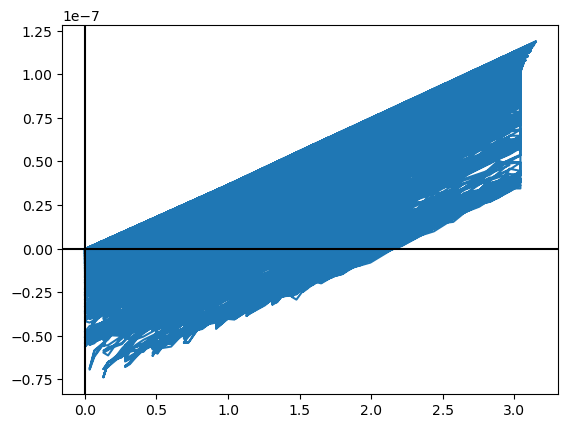

In [70]:
fig, ax = plt.subplots()
ax.plot(np.abs(xx),yy)
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

... I am not quite sure what is visible here. However, linear dependence is obvious. k_0 works better. Perhaps I can just subtract the k_0 term and work out the O(3) terms afterwords. 

# Remainder and Linear Term

In [77]:
np.shape(intercept2)

(21, 21)

In [78]:
remainder2 = intercept2
remainder3 = np.zeros((n_g,n_g))

for i in range(n_g):
    for j in range(n_g):
        remainder3[i,j] = remainder2[i,j] - slope_0_d*np.abs(dgrid[i,j])**2

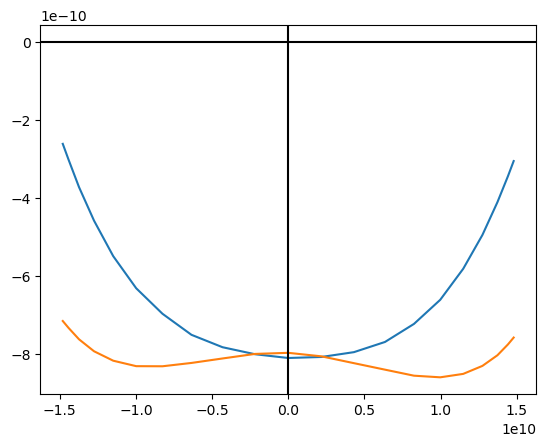

In [91]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.imag(dgrid[:,d1]),remainder3[:,d1])
ax.plot(np.imag(dgrid[:,d2]),remainder3[:,d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

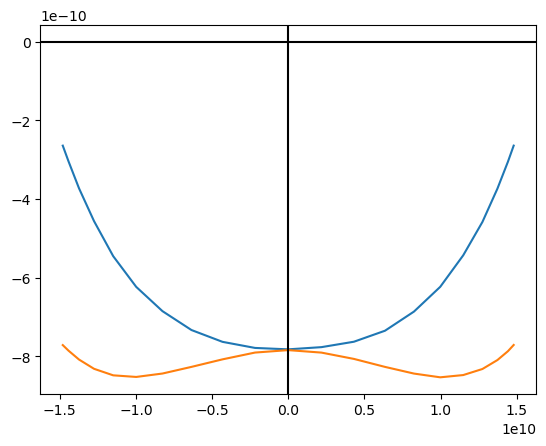

In [89]:
d1 = 2
d2 = 11

fig, ax = plt.subplots()
ax.plot(np.real(dgrid[d1]),remainder3[d1])
ax.plot(np.real(dgrid[d2]),remainder3[d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

Fourth-order term. Of course ... I think the fourth order term will be needed, but the sixth-order will not. Note that in the imaginary there is also a linear component -- orders of imag(psi'), not just psi' ** 2.

Linear regression to a function of the form 
\begin{equation}
a_1 \Re(\Psi^\prime) ^4 + a_2 \Re(\Psi^\prime) ^2 \Im(\Psi^\prime) ^2 + a_3 \Im(\Psi^\prime) ^4 + a_4 \Re(\Psi^\prime)^2 + a_5 \Im(\Psi^\prime)^2 +a_6 \Im (\Psi^\prime) + a_7
\end{equation}

Perhaps there are A_0 coupling terms as well.

Expected terms come from this equation:

\begin{equation}
|a|^2+|b|^2 = \frac{|\Psi^\prime_0|^2}{2 k^2} + \frac{|\Psi_0|^2}{2} \left(1+\frac{M^2}{k^2}\right) - \Psi_0 \frac{M}{k} \frac{\Im(\Psi^\prime_0)}{k}
\end{equation}

And without the M^2/k^2 term:
\begin{equation}
|a|^2+|b|^2 = \frac{|\Psi^\prime_0|^2}{2 k^2} + \frac{|\Psi_0|^2}{2} - \Psi_0 \frac{M}{k} \frac{\Im(\Psi^\prime_0)}{k}
\end{equation}

In [127]:
remainder4 = np.zeros((n_g,n_g))

for i in range(n_g):
    for j in range(n_g):
        remainder4[i,j] = remainder2[i,j] - slope_0_d*np.abs(dgrid[i,j])**2+np.sqrt(2)*slope_0_d*np.imag(dgrid[i,j])*gridl.l_calc.M

In [104]:
slope_0_d/t_new**2*eelib.pi**2

3.6930238577824506e-08

In [103]:
slope_A

3.772390428468754e-08

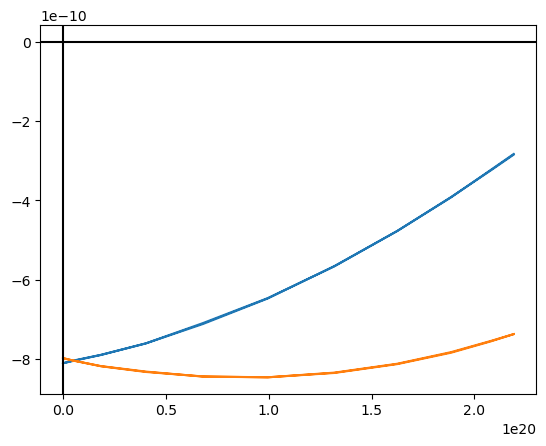

In [128]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.imag(dgrid[:,d1])**2,remainder4[:,d1])
ax.plot(np.imag(dgrid[:,d2])**2,remainder4[:,d2])
plt.axline((0,0), (1e-12,0), color='k')
plt.axline((0,0), (0,1e-12), color='k')
plt.show()

I like sqrt(2) here for the linear term. I still see a slight separation, but it is good. I wonder if this is actually ave(A_0). NO.. Perhaps unrelated to A_0.
I can see if a better estimate for the slope gets closer to the correct line.

In [130]:
np.sqrt(np.average(amp))

1.3228756555322954

Our 4th power terms are then here: 
\begin{equation}
\frac{|\Psi^\prime_0|^4}{4 k^4}, \quad 
\frac{|\Psi^\prime_0|^2 |\Psi_0|^2}{2 k^2} \left(1+\frac{M^2}{k^2}\right), \quad 
\frac{M \Psi_0 |\Psi^\prime_0|^2  \Im(\Psi^\prime_0)}{k^4}, \quad
\frac{|\Psi_0|^4}{4} \left(1+\frac{M^2}{k^2}\right)^2, \quad 
\Psi_0^3 \left(1+\frac{M^2}{k^2}\right) \frac{M}{k} \frac{\Im(\Psi^\prime_0)}{k}, \quad 
\Psi_0^2 \frac{M^2}{k^2} \frac{\Im(\Psi^\prime_0)^2}{k^2}
\end{equation}

Without M^2 / k^2:
\begin{equation}
\frac{|\Psi^\prime_0|^4}{4 k^4}, \quad 
\frac{|\Psi^\prime_0|^2 |\Psi_0|^2}{2 k^2} , \quad 
\frac{M \Psi_0 |\Psi^\prime_0|^2  \Im(\Psi^\prime_0)}{k^4}, \quad
\frac{|\Psi_0|^4}{4} , \quad 
\Psi_0^3  \frac{M}{k} \frac{\Im(\Psi^\prime_0)}{k}
\end{equation}

# Quartic Terms

In [131]:
from sklearn.linear_model import LinearRegression

In [132]:
np.shape(remainder4)

(21, 21)

In [136]:
X = np.zeros((n_g**2,6))
y = np.zeros((n_g**2))

for ii in range(n_g):
    for jj in range(n_g):
        X[ii*n_g + jj] = np.array([np.real(dgrid[ii,jj])**4, np.real(dgrid[ii,jj])**2*np.imag(dgrid[ii,jj])**2, np.imag(dgrid[ii,jj])**4, 
                                   np.real(dgrid[ii,jj])**2, np.imag(dgrid[ii,jj])**2,np.imag(dgrid[ii,jj])])
        y[ii*n_g + jj] = remainder4[ii,jj]

In [137]:
reg = LinearRegression().fit(X, y)

reg.score(X, y)

0.9639889511571801

In [138]:
reg.coef_

array([ 1.50043429e-51,  1.01422164e-50,  1.68384418e-51,  8.16975837e-71,
        7.67955416e-72, -5.30897681e-98])

In [140]:
slope_0_d

2.5644663335438e-28

In [141]:
X = np.zeros((n_g**2,3))
y = np.zeros((n_g**2))

for ii in range(n_g):
    for jj in range(n_g):
        X[ii*n_g + jj] = np.array([np.real(dgrid[ii,jj])**4, np.real(dgrid[ii,jj])**2*np.imag(dgrid[ii,jj])**2, np.imag(dgrid[ii,jj])**4])
        y[ii*n_g + jj] = remainder4[ii,jj]

In [142]:
reg = LinearRegression().fit(X, y)

reg.score(X, y)

0.9639889511571801

In [143]:
reg.coef_

array([1.50043429e-51, 1.01422164e-50, 1.68384418e-51])

In [144]:
reg.intercept_

-8.740934838261812e-10

Linear and quadratic terms are already removed. There may be a correction with A_0 terms or non-linear mu terms. Here we have only quartic terms left.

In [146]:
slope_4_d = reg.coef_
print(slope_4_d/t_new**4*eelib.pi**4)

[3.11162464e-11 2.10330908e-10 3.49198302e-11]


In [148]:
remainder5 = np.zeros((n_g,n_g))

for i in range(n_g):
    for j in range(n_g):
        remainder5[i,j] = remainder4[i,j] - np.matmul(slope_4_d,np.array([np.real(dgrid[i,j])**4, np.real(dgrid[i,j])**2*np.imag(dgrid[i,j])**2, np.imag(dgrid[i,j])**4]).T)

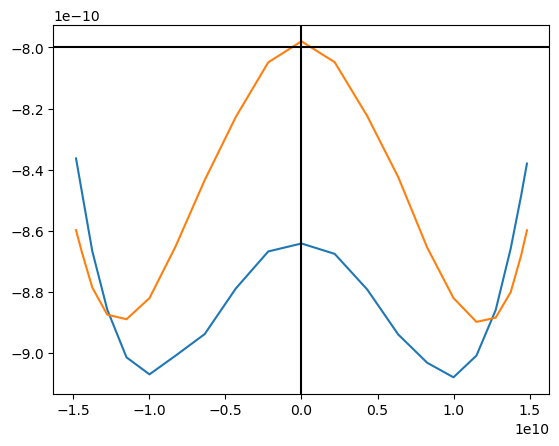

In [154]:
d1 = 2
d2 = 12

fig, ax = plt.subplots()
ax.plot(np.imag(dgrid[:,d1]),remainder5[:,d1])
ax.plot(np.imag(dgrid[:,d2]),remainder5[:,d2])
plt.axline((0,-8e-10), (1e-12,-8e-10), color='k')
plt.axline((0,-8e-10), (0,-8.5e-10), color='k')
plt.show()

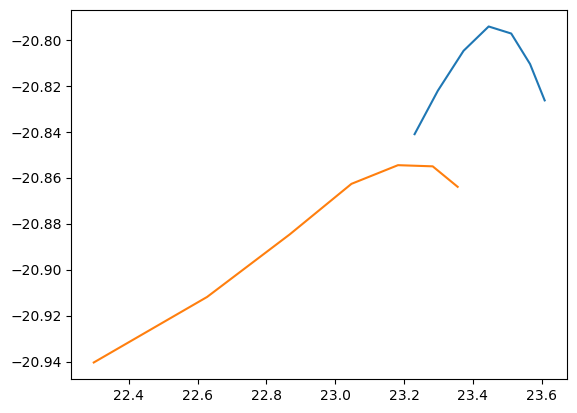

In [178]:
d1 = 4
d2 = 11

fig, ax = plt.subplots()
ax.plot(np.log(abs(dgrid[d1, 12:19])),np.log(-remainder5[d1, 12:19]))
ax.plot(np.log(abs(dgrid[d2, 12:19])),np.log(-remainder5[d2, 12:19]))
#plt.axline((0,-8e-10), (1e-12,-8e-10), color='k')
#plt.axline((0,-8e-10), (0,-8.5e-10), color='k')
plt.show()

Non-linear, not a power law (although may just be an intercept issue), ... I think the rest either requires examining relationships with other terms or will just remain. I don't know if it is required to remove the other terms. I will need to check how close my error is to my tolerance.

# Calculation of Remaining Terms

Lets calculate the difference between fot and our calculated results first. Then we can see if we can find linear fits to any other remaining terms, which can then be added to our calculated results. 

In [215]:
f_dt_A2 = np.zeros((n_m, n_k, n_g, n_g))
g_fun = np.zeros((n_m, n_k, n_g, n_g))
for nn in range(n_m): 
    for ii in range(n_k):
        for jj in range(n_g):
            for kk in range(n_g):
                # mu = 0 period
                g_fun[nn,ii,jj,kk] = fot[nn,ii,jj,kk] - t_new 
                # A_0 quadratic term
                #g_fun[nn,ii,jj,kk] = g_fun[nn,ii,jj,kk] / nls[ii]
                g_fun[nn,ii,jj,kk] -= slope_A*amp[ii]**2 *nls[nn]
                # linear and quadratic terms for psi '
                g_fun[nn,ii,jj,kk] -= slope_0_d*np.abs(dgrid[jj,kk])**2 *nls[nn] - np.sqrt(2)*slope_0_d*np.imag(dgrid[jj,kk])*gridl.l_calc.M * nls[nn]
                # quartic psi ' terms
                g_fun[nn,ii,jj,kk] -= nls[nn]*np.matmul(slope_4_d,np.array([np.real(dgrid[i,j])**4, 
                                                                    np.real(dgrid[i,j])**2*np.imag(dgrid[i,j])**2, 
                                                                    np.imag(dgrid[i,j])**4]).T)


In [216]:
np.max(g_fun), np.min(g_fun)

(5.810924358574203e-14, -3.541950100066034e-14)

I need to find slope dependencies on M and k ....

In [217]:
size = np.shape(foa.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

print(size == n_k* n_m * n_g**2)

sz = [n_k * n_g **2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ia in range(n_k):
        for idr in range(n_g):
            for idi in range(n_g):
                ind = imu*sz[0]+ia*sz[1]+idr*sz[2]+idi
                #npaf[ind, 0] = mfp[im]
                #npaf[ind, 1] = ew[ik]
                npaf[ind, 0] = nls[imu]
                npaf[ind, 1] = amp[ia]
                npaf[ind, 2] = np.real(dgrid[idr, idi])
                npaf[ind, 3] = np.imag(dgrid[idr, idi])
                npaf[ind, 4] = foa[imu, ia, idr, idi]
                npaf[ind, 5] = g_fun[imu, ia, idr, idi]

88200
True


# Triangle Plots 2nd Time

In [ ]:
import pandas as pd

dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "T fast"])

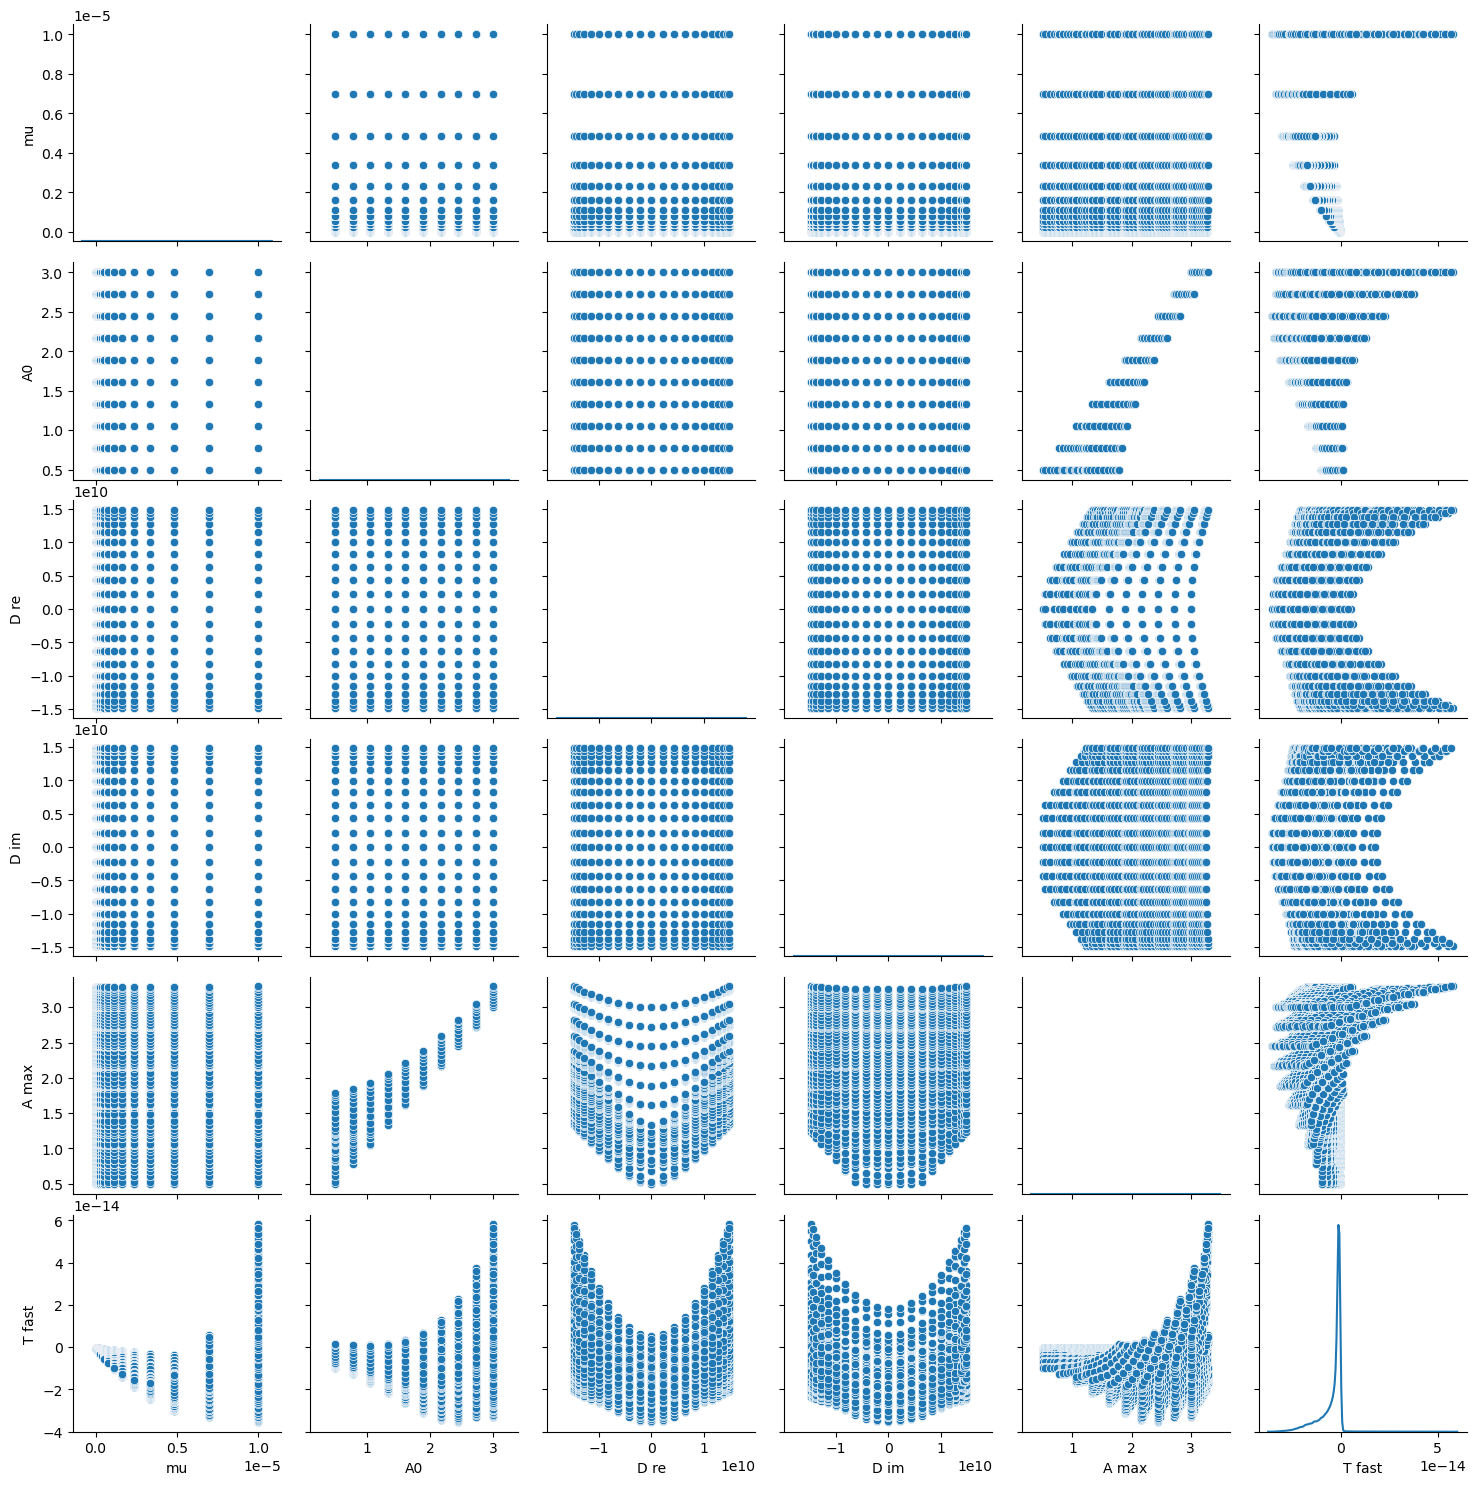

In [ ]:
#visualization
import seaborn as sns #statistical data visualization
#import matplotlib
#import matplotlib.pyplot as plt
#from mpl_toolkits import Axes3D #projection
#import plotly.express as px #3D plot



g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

In [ ]:
#t_0 = eelib.pi/eelib.kFAu
#npaf[:,-1]= npaf[:,-1]-t_new
#npaf[:,-1]= npaf[:,-1] / npaf[:,0]
#npaf[:,0]=np.power(npaf[:,0], 1/4)
npaf[:,1]=np.power(npaf[:,1],2)
#npaf[:,2]=np.power(npaf[:,2],2)
#npaf[:,3]=np.power(npaf[:,3],2)

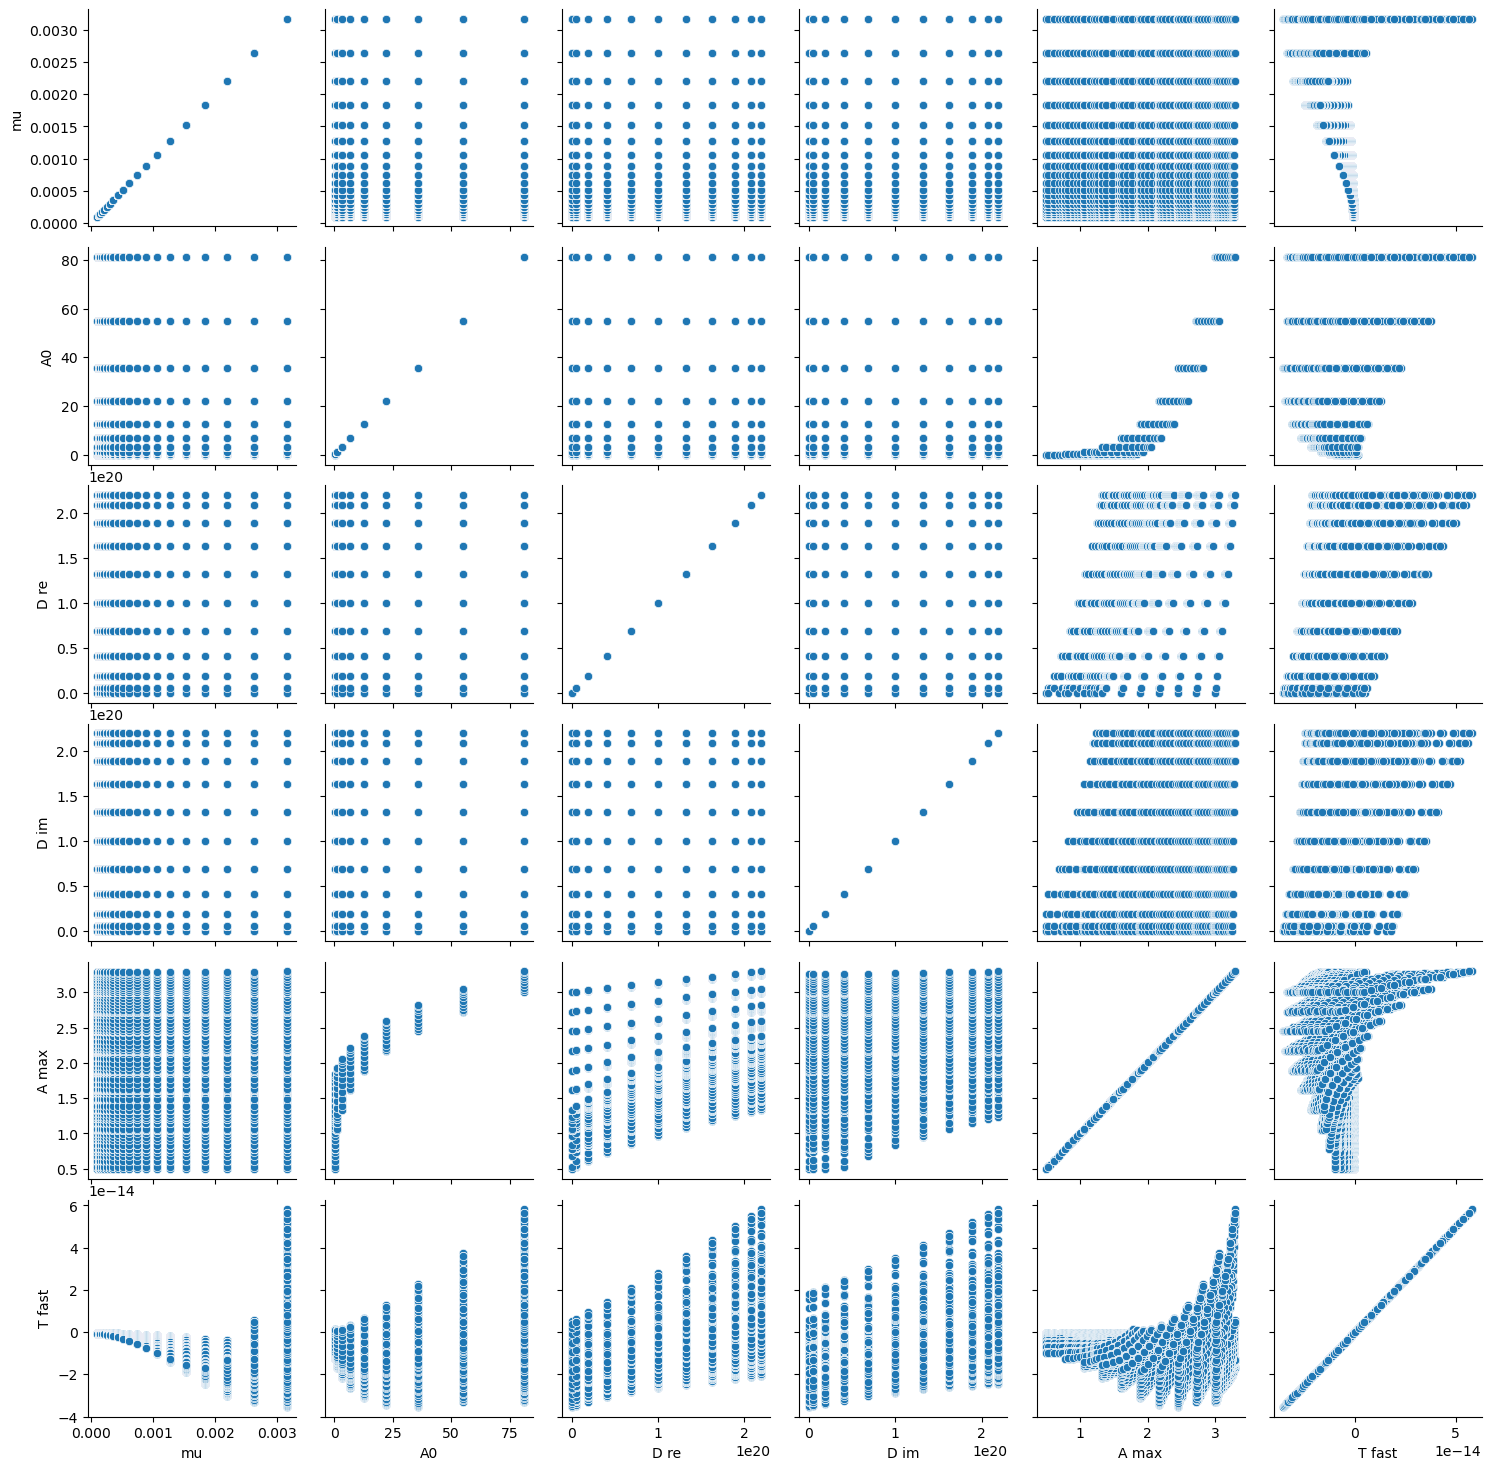

In [ ]:
#dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "T fast"])

g = sns.PairGrid(dfa)
g.map(sns.scatterplot)

mu and sqrt mu terms, all multiplied by one or the other

there is an a^4 term in here

psi' ^2 terms are dominant, but also real and imag are independent, and there is something else

# Separation of remaining linear and quadratic terms for mu

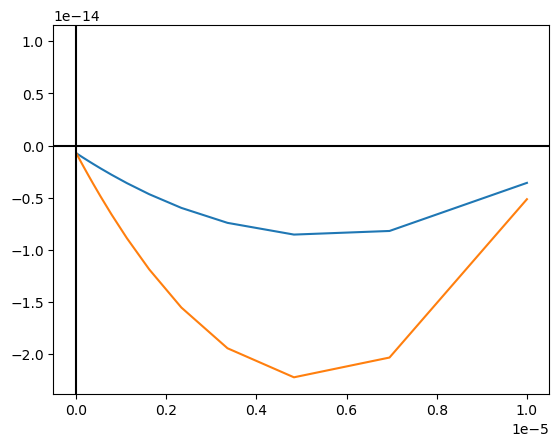

In [259]:
k1 = 3
k2 = 8
d1 = 0
d2 = 17
d3 = 1
d4 = 8

fig, ax = plt.subplots()
ax.plot(nls,g_fun[:, k1,d1,d2])
ax.plot(nls,g_fun[:, k2,d3,d4])
plt.axline((0,0), (1e-14,0), color='k')
plt.axline((0,0), (0,1e-14), color='k')
plt.show()

In [254]:
np.min(g_fun[0,:,:,:])

-8.450346062635081e-16

In [236]:
X = np.array([nls, np.sqrt(nls)]).T
np.shape(X)

(20, 2)

In [239]:
y = g_fun[:, i, j, k]
np.shape(y)

(20,)

In [ ]:
slope = np.zeros((n_k,n_g,n_g,2))
intercept = np.zeros((n_k,n_g,n_g))
r = 1.1    # for finding the minimum r value

for i in range(n_k):
    for j in range(n_g):
        for k in range(n_g):
            #X = np.array([g_fun[:, i, j, k], np.power(g_fun[:,i,j,k],2)]).T
            X = np.array([nls, np.power(nls,2)]).T
            y = g_fun[:, i, j, k]
            #y = nls

            reg = LinearRegression().fit(X, y)

            slope[i,j,k]=reg.coef_
            intercept[i,j,k]=reg.intercept_

            r2 = reg.score(X, y)
            #p = max(p, p2)
            #se = max(se, se2)
            r = min(r, r2)

            print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0 0 0 [-1.45683028e-09  1.63460826e-04] -4.761818961515713e-16 0.9999272118424314
0 0 1 [-1.43933737e-09  1.55713458e-04] -5.079859515326593e-16 0.9999507355614605
0 0 2 [-1.41181147e-09  1.42086336e-04] -5.274998372563617e-16 0.9999916153451314
0 0 3 [-1.37004740e-09  1.25079263e-04] -5.467573184073367e-16 0.9999523577962655
0 0 4 [-1.33887475e-09  1.06795886e-04] -5.302834395130584e-16 0.999994277607212
0 0 5 [-1.29494655e-09  8.91951897e-05] -5.613435358924241e-16 0.9999987829993574
0 0 6 [-1.25143721e-09  7.31384886e-05] -6.1090298998045e-16 0.9999991728756811
0 0 7 [-1.21907913e-09  6.05931461e-05] -6.473421841403593e-16 0.9999995430750716
0 0 8 [-1.19058359e-09  5.13821421e-05] -6.848307738311266e-16 0.9999956996278345
0 0 9 [-1.18729221e-09  4.69956524e-05] -6.604223850507113e-16 0.9999836425528266
0 0 10 [-1.16673138e-09  4.40018481e-05] -7.107492597420187e-16 0.9999998983122026
0 0 11 [-1.17317864e-09  4.58491565e-05] -6.613855370868295e-16 0.9999998920490846
0 0 12 [-1.193353

This works beautifully. The only issue is the intercept term. I should solve for this as a function of my other parameters, but ... 

Slope 0 is the linear term, slope 1 is the quadratic term, intercept is the constant term

In [261]:
slope_lin = slope[:,:,:,0]
slope_quad = slope[:,:,:,1]

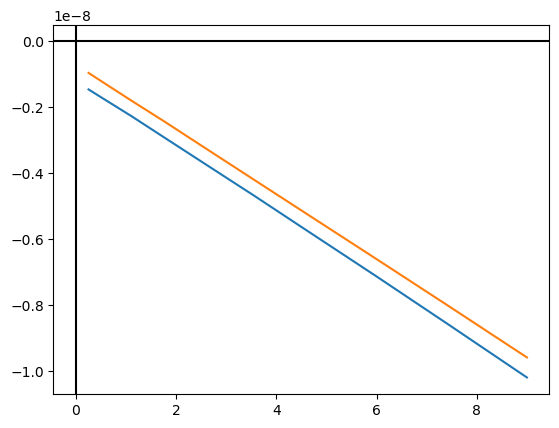

In [266]:
d1 = 0
d2 = 0
d3 = 13
d4 = 12

fig, ax = plt.subplots()
ax.plot(amp**2,slope_lin[:, d1,d2])
ax.plot(amp**2,slope_lin[:, d3,d4])
plt.axline((0,0), (1e-14,0), color='k')
plt.axline((0,0), (0,1e-14), color='k')
plt.show()

This appears to be an amp^2 component ... Coupling is minor if it exists

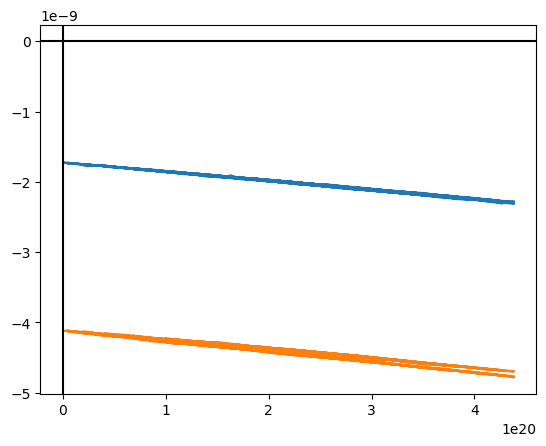

In [268]:
k1=2
k2=5

fig, ax = plt.subplots()
ax.plot(np.abs(dgrid.flatten())**2,slope_lin[k1, :,:].flatten())
ax.plot(np.abs(dgrid.flatten())**2,slope_lin[k2, :,:].flatten())
#ax.plot(amp**2,slope_lin[:, d3,d4])
plt.axline((0,0), (1e-14,0), color='k')
plt.axline((0,0), (0,1e-14), color='k')
plt.show()

Also parallel. There is a separation, indicating abs doesn't give all the dependence. ...

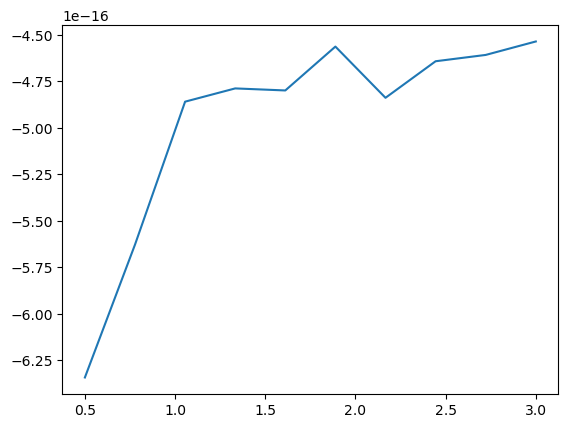

In [303]:
d1 = 2
d2 = 2
d3 = 11
d4 = 11

fig, ax = plt.subplots()
#ax.plot(amp,intercept[:, d1,d2])
ax.plot(amp,intercept[:, d3,d4])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

Error? This doesn't look very straight in any obvious function. It is possible that there are several subdominate terms here. Even without the derivative term, ...

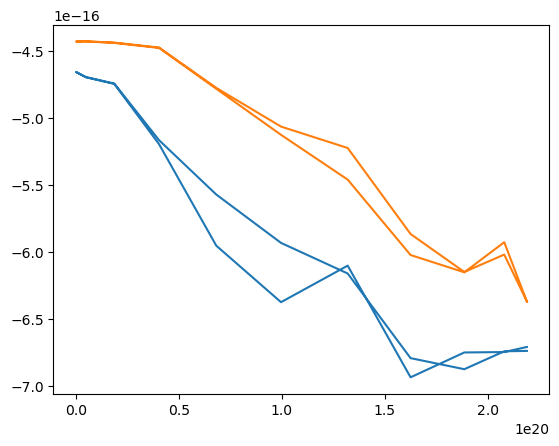

In [309]:
k1 = 2
k2 = 8
d1 = 2
d2 = 2

fig, ax = plt.subplots()
ax.plot(dlist**2,intercept[k1, :,d1])
ax.plot(dlist**2,intercept[k2, :,d2])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

I could get a line from this

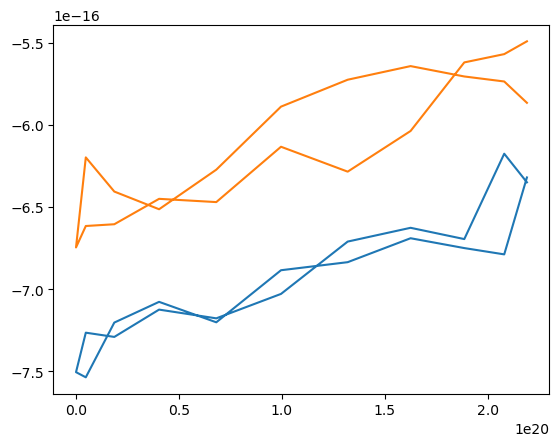

In [316]:
k1 = 2
k2 = 9
d1 = 2
d2 = 2

fig, ax = plt.subplots()
ax.plot(dlist**2,intercept[k1, d1,:])
ax.plot(dlist**2,intercept[k2, d2, :])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

There is a line here as well. Low confidence, however. I am at the edge of my emergent behavior.

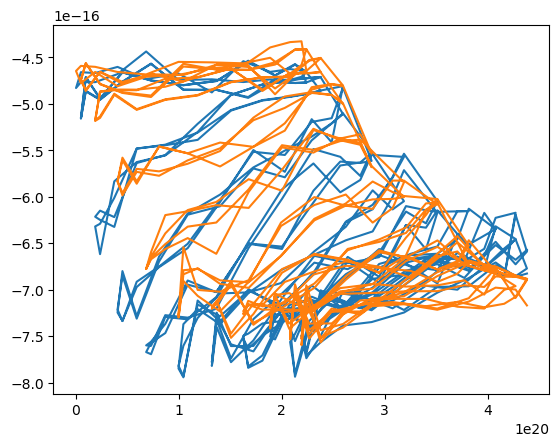

In [318]:
k1=2
k2=5

fig, ax = plt.subplots()
ax.plot(np.abs(dgrid.flatten())**2,intercept[k1, :,:].flatten())
ax.plot(np.abs(dgrid.flatten())**2,intercept[k2, :,:].flatten())
#ax.plot(amp**2,slope_lin[:, d3,d4])
#plt.axline((0,0), (1e-14,0), color='k')
#plt.axline((0,0), (0,1e-14), color='k')
plt.show()

Chaos

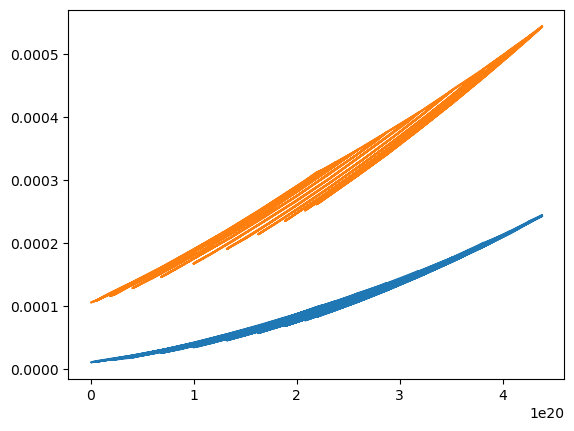

In [319]:
k1=2
k2=5

fig, ax = plt.subplots()
ax.plot(np.abs(dgrid.flatten())**2,slope_quad[k1, :,:].flatten())
ax.plot(np.abs(dgrid.flatten())**2,slope_quad[k2, :,:].flatten())
#ax.plot(amp**2,slope_lin[:, d3,d4])
#plt.axline((0,0), (1e-14,0), color='k')
#plt.axline((0,0), (0,1e-14), color='k')
plt.show()

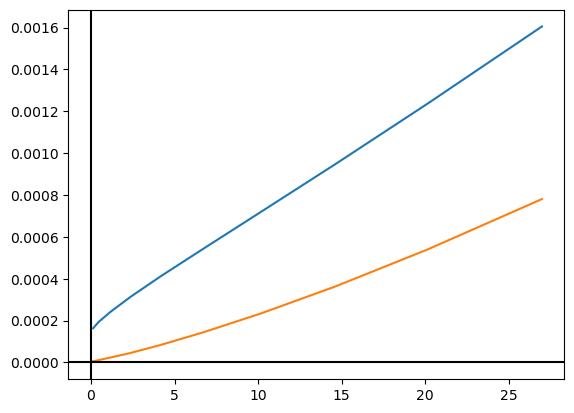

In [322]:
d1 = 0
d2 = 0
d3 = 13
d4 = 12

fig, ax = plt.subplots()
ax.plot(amp**3,slope_quad[:, d1,d2])
ax.plot(amp**3,slope_quad[:, d3,d4])
plt.axline((0,0), (1e-14,0), color='k')
plt.axline((0,0), (0,1e-14), color='k')
plt.show()

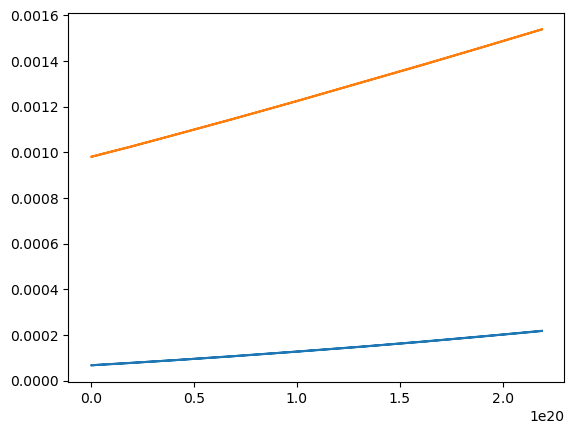

In [323]:
k1 = 2
k2 = 9
d1 = 2
d2 = 2

fig, ax = plt.subplots()
ax.plot(dlist**2,slope_quad[k1, d1,:])
ax.plot(dlist**2,slope_quad[k2, d2, :])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

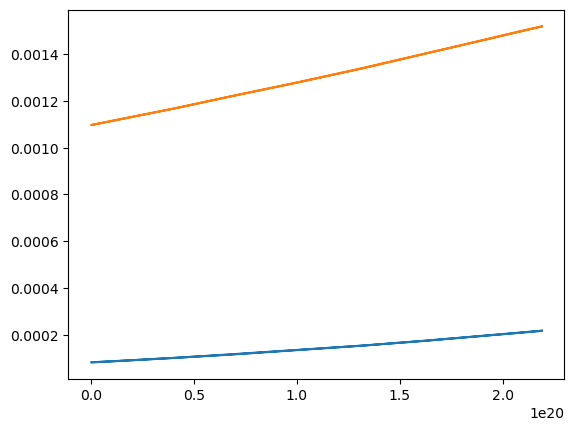

In [324]:
k1 = 2
k2 = 9
d1 = 2
d2 = 2

fig, ax = plt.subplots()
ax.plot(dlist**2,slope_quad[k1, :,d1])
ax.plot(dlist**2,slope_quad[k2, :,d2])
#plt.axline((0,0), (-1e-16,0), color='k')
#plt.axline((0,0), (0,-1e-16), color='k')
plt.show()

Amp is not quadratic, psi' rather quadratic. Once I get these terms, it should be enough. 

# Triangle Plots

In [218]:
import pandas as pd

dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "T fast"])

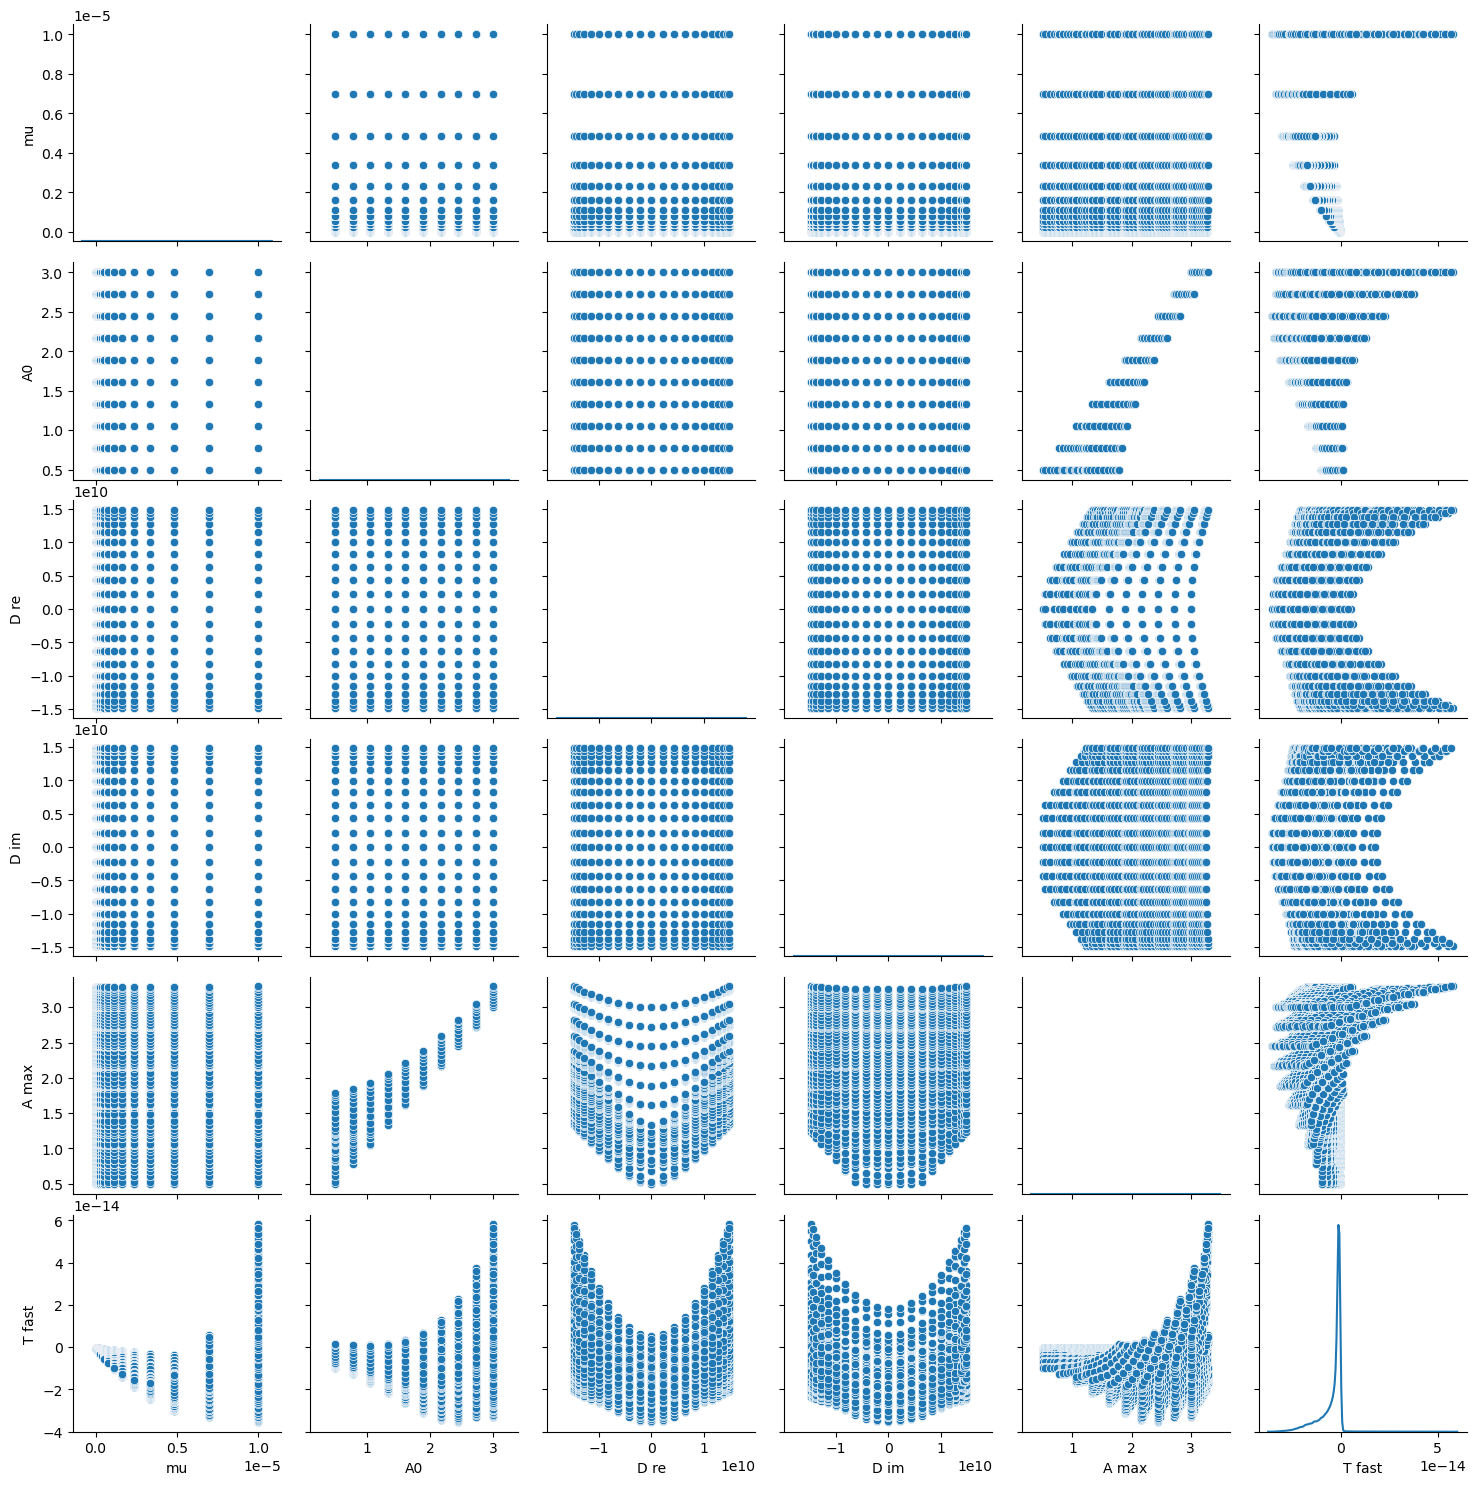

In [221]:
#visualization
import seaborn as sns #statistical data visualization
#import matplotlib
#import matplotlib.pyplot as plt
#from mpl_toolkits import Axes3D #projection
#import plotly.express as px #3D plot



g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

In [228]:
#t_0 = eelib.pi/eelib.kFAu
#npaf[:,-1]= npaf[:,-1]-t_new
#npaf[:,-1]= npaf[:,-1] / npaf[:,0]
#npaf[:,0]=np.power(npaf[:,0], 1/4)
npaf[:,1]=np.power(npaf[:,1],2)
#npaf[:,2]=np.power(npaf[:,2],2)
#npaf[:,3]=np.power(npaf[:,3],2)

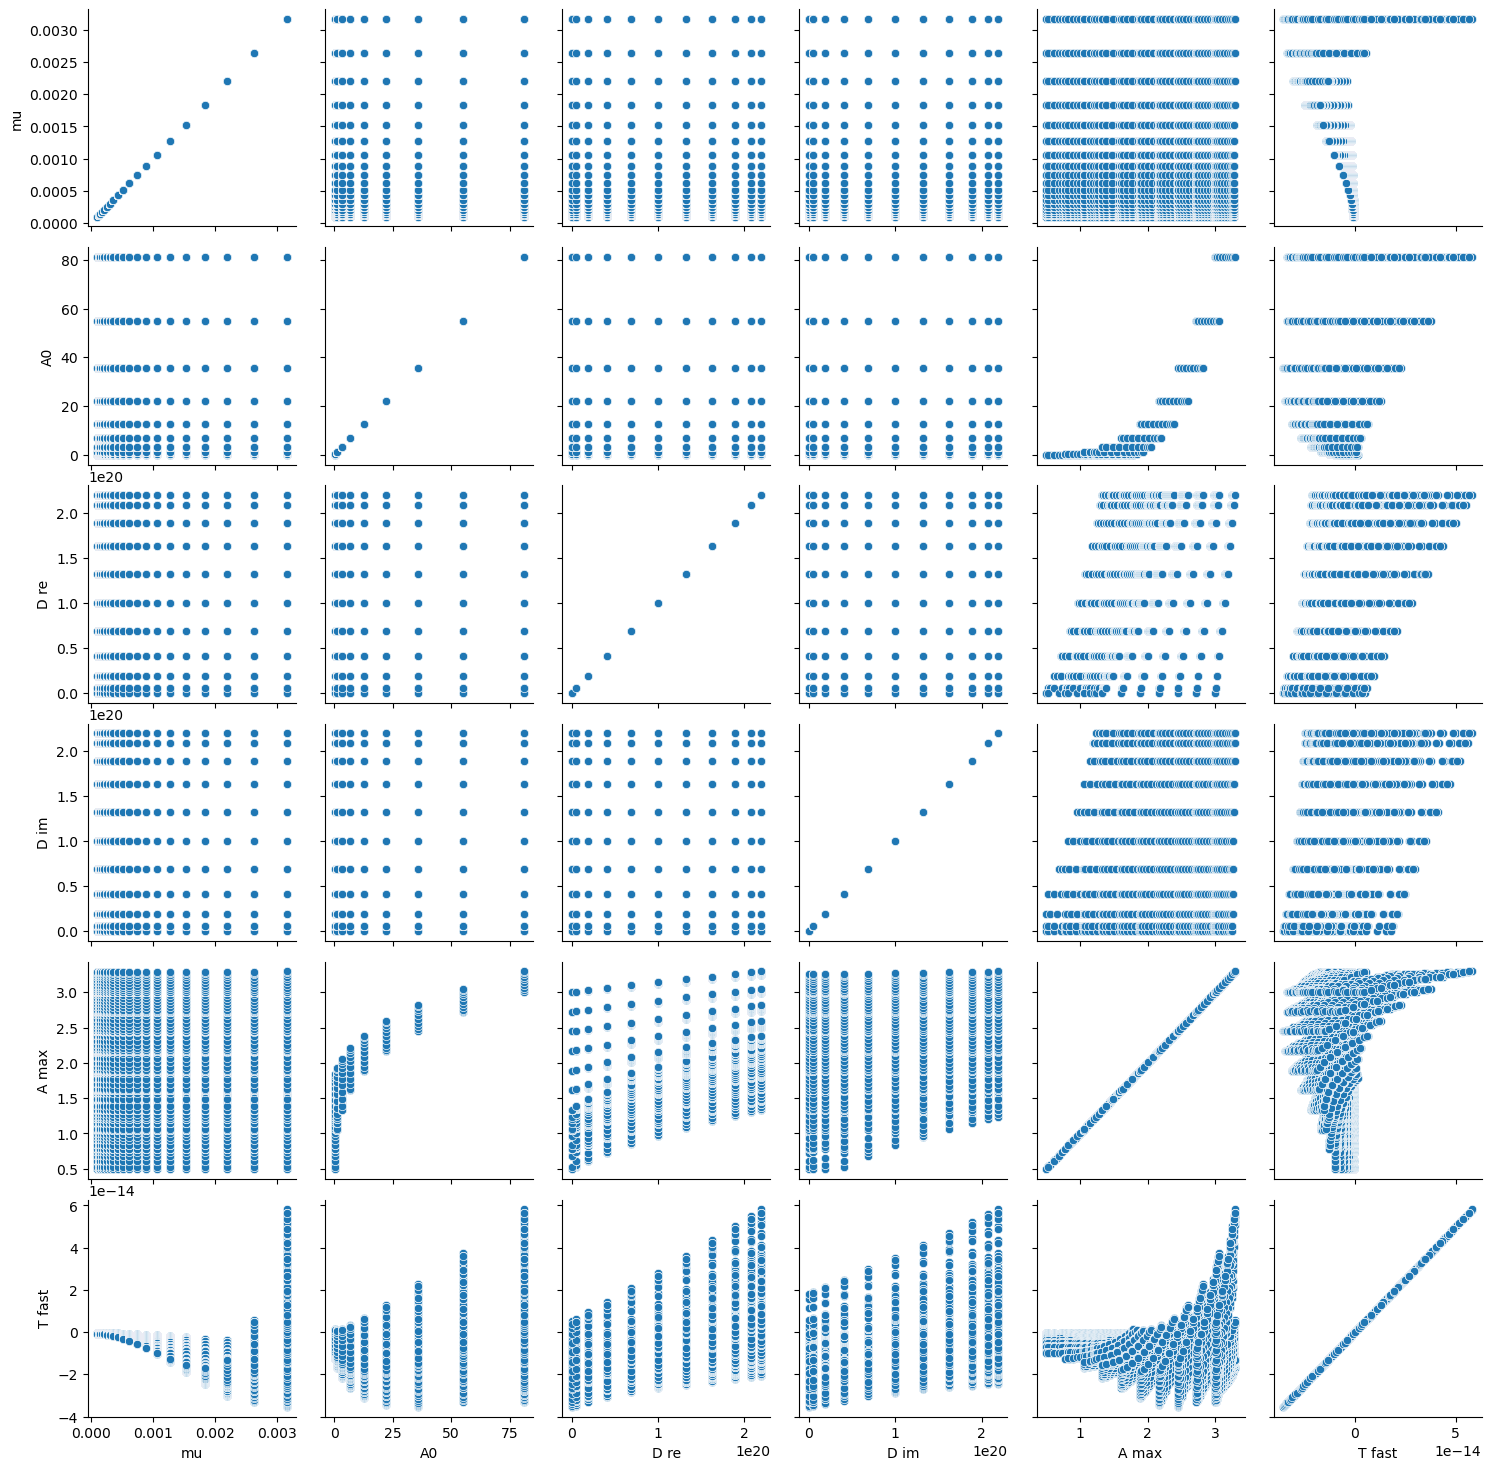

In [229]:
#dfa = pd.DataFrame(npaf, columns = ["mu", "A0", "D re", "D im", "A max", "T fast"])

g = sns.PairGrid(dfa)
g.map(sns.scatterplot)

mu and sqrt mu terms, all multiplied by one or the other

there is an a^4 term in here

psi' ^2 terms are dominant, but also real and imag are independent, and there is something else

In [ ]:
npaf[:,2]

In [51]:
npaf[:,-1]= npaf[:,-1] *npaf[:,1]*npaf[:,1]

In [80]:
npaf[:,0]=np.power(npaf[:,0],2)

In [72]:
npaf[:,3]=np.power(npaf[:,3],2)